<a href="https://colab.research.google.com/github/nehaj2026/undergrad_ml_assignments/blob/main/NJ_03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

# **Q1.** Please answer the following questions in your own words.


1.   **What makes a model "linear"? "Linear" in what?**

A model is linear when the parameters for the model are linear. This means the coefficients in the model are not being transformed in a nonlinear way. Additionally, this essentially means that the relationship between the predictor and the explanatory variables are modeled in a linear way (as in a line).

2. **How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)**

The coefficient of a dummy variable is a measure of the difference between the prediction and the reference category (which is the intercept). The intercept itself is the predicted value when the dummy variable is 0. When the dummy variable is 1, the coefficient shows how much the prediction changes compared to when the dummy variable is 0.

3. **Can linear regression be used for classification? Explain why, or why not.**

Since classification is usually focused on predicting discrete, binary categorical variables variables and linear regression predicts continuous numbers, it is not the best to use. However, it can be used for classification and can predict 0 and 1 for the class. But, linear regression only assumes these binary outcomes and it is extremely sensitive to outliers. So, while it could be used for binary classification, I would prefer to use logistic regression since it models the probabilities of classes that are predicted properly.

4. **What are signs that your linear model is over-fitting?**

One of the clearest signs of over-fitting is that the model performs well on training data (high accuracy) but poorly on testing data. This indicates that the model has been trained on the "noise" in the training set, which may occur because of it being too complex or there being too many attributes, which would lead to over-fitting.

5. **Clearly explain multi-colinearity using the two-stage least squares technique.**

Multicolinearity occurs when independent variables are highly correlated with one another, which makes it hard to isolate the individual effect of each of the variables on the dependent variable. Since two-stage least squares is used to address cases where the explanatory variable is correlated with the error term, in order to address multi-colinearity, the correlated variable can be replaced with a variable that is correlated witht eh independent variable byt not the error term (as in an endogenous variable). The regression with this variable replaced removes the problematic shared variance that was between the variables. Thus, two-stage least squares reduces the impact of multicolinearity by isolating the variation in the problematic variable and prevents estimates from being distorted.


6. **How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable y and your features/control/response/independent variables x into your analysis?**

The first way to incorporate nonlinear relationships between the target variable and the features is to create an interaction term by multiplying two variables together. This captures how the effect of one variable changes depending on another. The second way to do this is one hot encoding. This allows us to treat a numeric variable as a categorical variable. This enables non-linear differences to be observed across groups.

7. **What is the interpretation of the slope coefficient in a linear regression?**

The slope coefficient is an estimatation for how much the dependent variable will change for every one unit increase in the independent variable, holding all other variables fixed. This is just a prediction/estimation though, as this is not a causal relationship we are examining.

8. **Compare the train/test split and k-fold cross validation.**

Train-test split splits the data once into one training set and one testing set. It makes sure that you are not testing the model on data it has already been trained on. K-fold cross validation repeats this split for training and testing for K iterations by splitting the data into K folds and training the data on K-1 folds and testing on that last fold. The results are averaged to give an estimate of model performance.

9. **How is the k in k-fold cross validation typically selected?**

The K selection is decided based on the bias-variance trade-off where a small K leads to a small training set and higher bias in the model. A really large K means that the model will take extremely long to run. In class, we used a k of 10, whch offers a fair balance between bias and variance.

In [1]:
#Loading Data

! git clone https://github.com/nehaj2026/scratchpad

Cloning into 'scratchpad'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 36 (delta 9), reused 6 (delta 6), pack-reused 23 (from 1)
Receiving objects: 100% (36/36), 64.98 KiB | 1.25 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()



Download complete
Extracting data files...
Data extracted


In [ ]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 67 (delta 23), reused 9 (delta 9), pack-reused 34 (from 2)
Receiving objects: 100% (67/67), 11.57 MiB | 22.57 MiB/s, done.
Resolving deltas: 100% (23/23), done.


# **Q2.** Load `./data/Q1_clean.csv`. The data include

Price per **night**
Review Scores Rating: The average rating for the property
Neighbourhood: The bourough of NYC. Note the space, or rename the variable.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/data/airbnb_hw.csv')
df.columns
df.dtypes
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

**Q2.1**: Compute the average prices and scores by Neighbourhood; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by Neighbourhood.

In [4]:
#Average prices by neighbourhood
df.groupby('Neighbourhood ')['Price'].mean()
#Manhattan is the most expensive bourough

,Price
Neighbourhood,
Bronx,83.308140
Brooklyn,124.595122
Manhattan,183.964571
Queens,100.012747
Staten Island,111.312500


In [5]:
#Average review scores by neighbourhood
df.groupby('Neighbourhood ')['Review Scores Rating'].mean()
#Brooklyn has the best review scores

,Review Scores Rating
Neighbourhood,
Bronx,91.654378
Brooklyn,92.363497
Manhattan,91.801785
Queens,91.549057
Staten Island,90.843750


<Axes: xlabel='Price', ylabel='Density'>

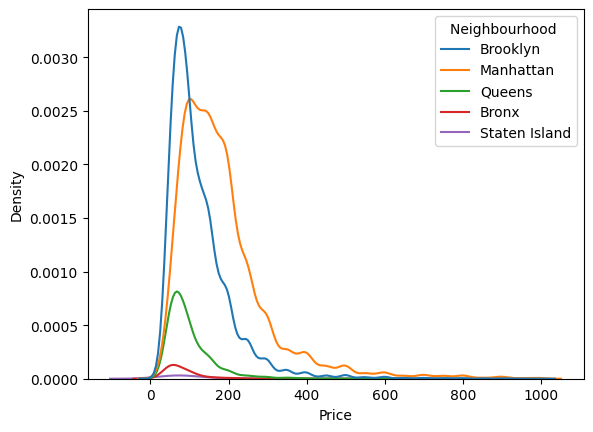

In [6]:
#kde plot of price grouping by neighborhood
import seaborn as sns
sns.kdeplot(data = df, x = 'Price', hue = 'Neighbourhood ')

<Axes: xlabel='Price', ylabel='Density'>

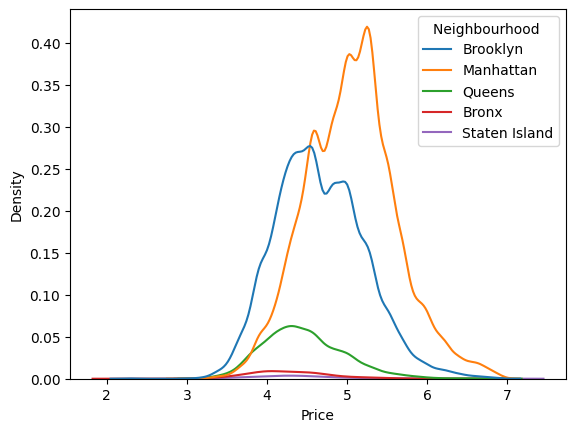

In [7]:
#kde plot of log of price grouping by neighborhood
sns.kdeplot(data = df, x = np.log(df['Price']), hue = 'Neighbourhood ')

**Q2.2**: Regress price on Neighbourhood by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [13]:
from sklearn.linear_model import LinearRegression

tdf = df.loc[:,['Price', 'Neighbourhood ']].dropna()
y = tdf['Price']
X = pd.get_dummies(tdf['Neighbourhood '], dtype = 'int', drop_first = True)

model = LinearRegression().fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

Model intercept: 83.3081395348837


,variable,coefficient
0,Brooklyn,41.286982
1,Manhattan,100.656432
2,Queens,16.704608
3,Staten Island,28.004360


#Q2.2 Part 2
In this question, I dropped the first category, which alphabetically was Bronx and made the mean of price of Bronx the baseline/the interecept. The coefficients from the the regression are the difference between each neighborhood mean and baseline mean from Bronx in the table from part 1. The regression coefficients are essentially recovering those conditional group means from part 1.

**Q2.3**: Regress price on Review Scores Rating and a constant/intercept. Interpret the slope coefficient clearly in words.

In [14]:
from sklearn.linear_model import LinearRegression

tdf = df.loc[:,['Price', 'Review Scores Rating']].dropna()
y = tdf['Price']
X = tdf.loc[:,['Review Scores Rating']]

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

#Slope interpretation
#For each additional point increase in Review Scores Rating, there is a mean increase of $0.99 in price, holding other factors constant.

Model intercept: 59.404942120702586


,variable,coefficient
0,Review Scores Rating,0.993871


**Q2.4**: Regress price on both Neighbourhood and Review Scores Rating. How does the slope coefficient on Review Scores Rating change? How do the neighborhood averages change?

In [ ]:
tdf = df.loc[:,['Price', 'Neighbourhood ', 'Review Scores Rating']].dropna()
y = tdf['Price']
X_num = tdf.loc[:, ['Review Scores Rating']]
X_cat = pd.get_dummies(tdf['Neighbourhood '], dtype = 'int', drop_first = True)
X = pd.concat([X_num, X_cat], axis = 1)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

#Slope Coefficient Changes:
#The Review Scores Rating coefficient increased from 0.99 in Q2.3 to 1.051 in this question
# Controlling for neighborhood, each additional Review Score Rating point is associated with a mean price increase of $1.051.


#Neighborhood Averages:
#In Q2.2 the neighborhood coefficient averages were reflecting raw price difference betweeen the neighbourhoods
# In this question, the coefficients reflect the price differences when controlling for Review Scores Rating
#Adding a new variable to the regression changes the other coefficients because each one is now representing its effect holding the other variables fixed

Model intercept: -21.083267521072855


,variable,coefficient
0,Review Scores Rating,1.051338
1,Brooklyn,49.222780
2,Manhattan,103.056308
3,Queens,21.691463
4,Staten Island,20.086757


**Q2.5**: Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for Review Scores Rating. Are the slopes similar across neighborhoods, or not?

In [15]:
tdf = df.loc[:,['Price', 'Neighbourhood ', 'Review Scores Rating']].dropna()
y = tdf['Price']

X_cat = pd.get_dummies(tdf['Neighbourhood '], dtype = 'int', drop_first = True)

X_interactions = X_cat.multiply(tdf['Review Scores Rating'], axis = 0)
X_interactions.columns = [f'{col}_x_rating' for col in X_cat.columns]

X_num = tdf.loc[:, ['Review Scores Rating']]
X = pd.concat([X_num, X_cat, X_interactions], axis = 1)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

#The slopes are not similar across neighborhoods as the slopes range from 0.269 to 1.133.
#Based on the slopes of Brooklyn (1.133) and Manhattan (1.099) being higher tha the other neighborhoods, the relationship between price and Review Scores Rating is stronger for these neighborhoods
#The relationship between rating and price is weaker in Quuens (slope of 0.502) and Staten Island (0.269)

Model intercept: 22.638384922079553


,variable,coefficient
0,Review Scores Rating,0.574311
1,Brooklyn,-2.098929
2,Manhattan,54.909417
3,Queens,28.259701
4,Staten Island,47.868599
5,Brooklyn_x_rating,0.559319
6,Manhattan_x_rating,0.525238
7,Queens_x_rating,-0.072294
8,Staten Island_x_rating,-0.305467


**Q2.6**: Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

tdf = df.loc[:,['Price', 'Neighbourhood ', 'Review Scores Rating']].dropna()
y = tdf['Price'].values
X_num = tdf.loc[:, ['Review Scores Rating']]
X_cat = pd.get_dummies(tdf['Neighbourhood '], dtype = 'int', drop_first = True)
X_interactions = X_cat.multiply(tdf['Review Scores Rating'].values, axis = 0)
X_interactions.columns = [f'{col}_x_rating' for col in X_cat.columns]

X_part3 = tdf.loc[:, ['Review Scores Rating']].values
X_part4 = pd.concat([X_num, X_cat], axis = 1).values
X_part5 = pd.concat([X_num, X_cat, X_interactions], axis = 1).values

kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

for question, X in [('Question 2.3', X_part3),
                ('Question 2.4', X_part4),
                ('Question 2.5', X_part5)]:

  scores = []
  for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

  print(f'{question}')
  print('Fold scores', scores)
  print('Mean score', np.mean(scores))
  print('Median score', np.median(scores))
  print('Standard deviation', np.std(scores))

  #The best models are the ones from Q2.4 and 2.5 since these have the lowest MSE

Question 2.3
Fold scores [10925.58514573569, 9534.192300227814, 9923.783793636614, 10661.789276177826, 10689.795417276187, 10834.819101950792, 8916.702879607561, 10228.88582015734, 9599.557283345504, 8447.820837495148]
Mean score 9976.293185561048
Median score 10076.334806896977
Standard deviation 804.9916175386102
Question 2.4
Fold scores [10089.557322434326, 8630.972008600782, 8949.51563914888, 9631.930216007708, 9564.822331937798, 9846.772661647641, 8036.588652014715, 9237.999234098499, 8751.471873587447, 7582.496325512672]
Mean score 9032.212626499047
Median score 9093.75743662369
Standard deviation 762.0210572990625
Question 2.5
Fold scores [10088.747257361763, 8638.648325322016, 8948.849020279436, 9629.997057966923, 9561.101018681604, 9845.606323109156, 8035.447499497643, 9234.880941321377, 8752.158213001543, 7577.8749130426195]
Mean score 9031.331056958406
Median score 9091.864980800407
Standard deviation 761.9004063316017


# **Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

Price: In Indian rupees
Seating_Capacity: Number of seats
Body_Type: crossover, hatchback, muv, sedan, suv
Make_Year: The year the car was made

**Q3.1**: Load cars_hw.csv. Summarize the Price variable and create a kernel density plot. Use .groupby() and .describe() to summarize prices by Body_Type. Make a grouped kernel density plot by Body_Type. Which car types are the most expensive? Which have the most variance?

In [16]:
#Loading dataset
import pandas as pd
df = pd.read_csv('/content/data/cars_hw.csv')
df

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000
...,...,...,...,...,...,...,...,...,...,...,...,...
971,972,Hyundai,2018,white,sedan,23869,1st,5,petrol,6-Speed,Automatic,956000
972,973,Hyundai,2019,white,sedan,14831,1st,5,petrol,6-Speed,Automatic,1027000
973,974,Hyundai,2014,silver,sedan,52846,1st,5,petrol,4-Speed,Automatic,736000
974,975,Ford,2020,white,crossover,28335,2nd,5,diesel,5-Speed,Automatic,749000


<Axes: xlabel='Price', ylabel='Density'>

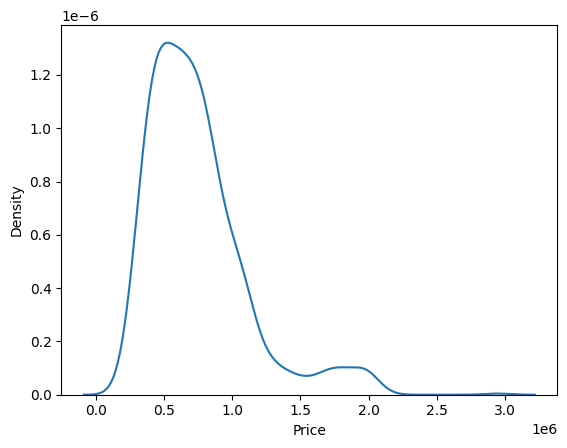

In [17]:
#Summarizing price variable
df['Price'].value_counts()
df['Price'].describe()

# The 'Price' variable has a mean price of $741k rupees
# 'Price' has significant volatility since the standard deviation is 367k rupees
#Also, there are only 976 cars, so it is important to note this may not be a sufficient sample to analyze the car market, which consists of more car models than just this subset contains


# Kde plot
import seaborn as sns
sns.kdeplot(data = df, x = 'Price')


In [18]:
#Summarizing prices by body_type
df.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


<Axes: xlabel='Price', ylabel='Density'>

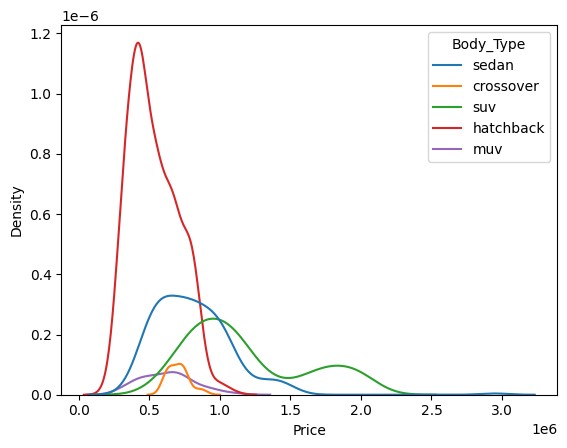

In [ ]:
#Grouped kernel density plot by Body_Type
sns.kdeplot(data = df, x = 'Price', hue = 'Body_Type')

#**Q3.1** Part 2:
The most expensive car types are SUVs, with sedans following behind them in second place. SUVs also have the greatest variance.

**Q3.2**: Regress Price on Seating_Capacity. What's the slope coefficient? Interpret it. Now treat Seating_Capacity as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

In [ ]:
#Regression of Price on Seating_Capacity and slope coefficient interpretation
from sklearn.linear_model import LinearRegression
tdf = df.loc[:,['Price', 'Seating_Capacity']].dropna()
y = tdf['Price']
X = tdf.loc[:,['Seating_Capacity']]

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_})

#The slope coefficient of 59267.998 means that for a in increase in seating of 1, there is an associated mean $59267.998 increase in price, holding other factors constant.

Model intercept: 439032.0141018266


,variable,coefficient
0,Seating_Capacity,59267.998037


In [ ]:
#Regression with one hot encoded Seating_Capacity
tdf = df.loc[:,['Price', 'Seating_Capacity']].dropna()
y = tdf['Price']
X_seating_capacity = pd.get_dummies(tdf['Seating_Capacity'], dtype = 'int', drop_first = True)
model_cat = LinearRegression().fit(X_seating_capacity, y)

print(f'Model intercept: {model_cat.intercept_}')
pd.DataFrame({'variable': X_seating_capacity.columns, 'coefficient': model_cat.coef_})

#The differences in price are not linear since for it to be linear, there would need to be roughly similar increases in price for each seat added.
#However, as seen, there is significant variability in the price increase, indicating the difference in price is not linear.


Model intercept: 188000.00000000314


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


**Q3.3**: Use Make_Year to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of Age to include in a regression of Price on Age.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

df['Age'] = np.max(df['Make_Year']) - df['Make_Year']
#Note: this is assuming that the age of newest car int he dataset is the current year

tdf = df.loc[:,['Price', 'Age']].dropna()
y = tdf['Price'].values
X = tdf.loc[:,['Age']].values

kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

for degree in range (1, 9):
  expander = PolynomialFeatures(degree = degree, include_bias = False)
  X_poly = expander.fit_transform(X)

  scores = []
  for train_idx, test_idx in kf.split(X_poly):
    X_train, X_test = X_poly[train_idx], X_poly[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

  print(f'Degree {degree}')
  print('Fold scores', scores)
  print('Mean score', np.mean(scores))
  print('Median score', np.median(scores))
  print('Standard deviation', np.std(scores))

  # On a purely MSE basis, Degree 8 is optimal for Age since this is where the mean MSE and the median MSE are the lowest
  #However, I would also say degree 5 since the decrease in MSE is minimal after degree 5, so higher degrees may be too complex

Degree 1
Fold scores [70109524470.3725, 95738380668.54692, 100947653940.73596, 142290185169.5995, 99479204035.59134, 102476852059.42833, 76999938853.61102, 100640657781.9177, 88350802968.45583, 96739280691.70882]
Mean score 97377248063.9968
Median score 98109242363.65009
Standard deviation 18205292694.11782
Degree 2
Fold scores [69817766385.22522, 95913543574.15846, 101074719871.04497, 142809684656.84827, 99131318090.71596, 102213425469.50822, 77081949882.44048, 100380142906.22751, 88798584291.39871, 96735924558.7831]
Mean score 97395705968.63509
Median score 97933621324.74953
Standard deviation 18332561997.851494
Degree 3
Fold scores [69603235629.76546, 95851113293.83156, 101153252307.09953, 142417235860.2715, 97216777650.95038, 101938300853.79129, 75389198505.30865, 99799704477.42365, 87712918675.97447, 96350310930.01595]
Mean score 96743204818.44325
Median score 96783544290.48315
Standard deviation 18485640071.596397
Degree 4
Fold scores [71185317094.60895, 95464552654.35638, 100791

**Q3.4**: Plot Price against Age, and then model-predicted price against Age. Does the model accurately fit the patterns in the data?

<Axes: xlabel='Age', ylabel='Price'>

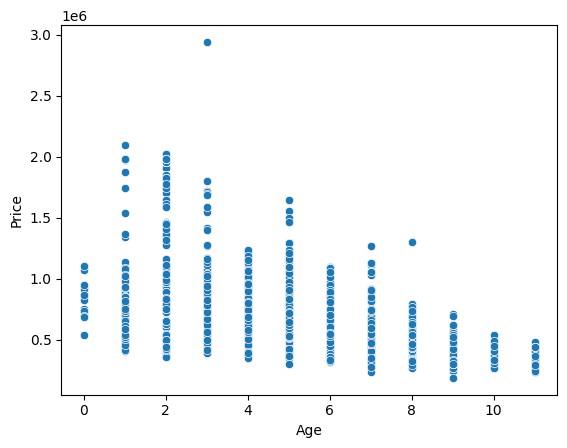

In [26]:
# Price against Age
#Note: I assumed going forward with degree 5 to avoid unnecessary complexity and to avoid risking overfitting
expander = PolynomialFeatures(degree = 5, include_bias = False)
X_poly = expander.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)
y_hat = model.predict(X_poly)

sns.scatterplot(data = tdf, x = 'Age', y = 'Price')

<Axes: xlabel='Age'>

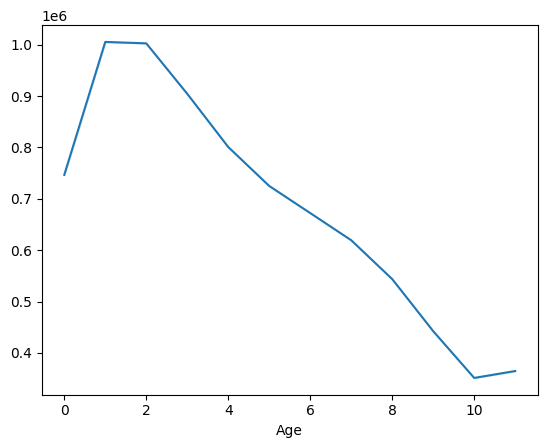

In [25]:
#Model-predicted Price against Age
sns.lineplot(data = tdf, x = 'Age', y = y_hat)

<Axes: xlabel='Age'>

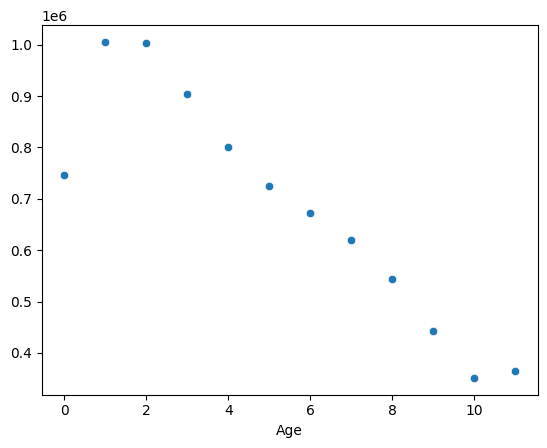

In [27]:
sns.scatterplot(data = tdf, x = 'Age', y = y_hat)

# Q3.4 Part 2:
The model does capture the downwards sloping trend where the higher the age of the car, the lower the predicted price of the car. However, there is a lot of variability of price at each age in the actual data which is not captured in the model, so the model lineplot is a more simplified version of the data that does not capture all of the factors affecting price.

# **Q4**. This question refers to the heart_hw.csv data. It contains three variables:

y: Whether the individual survived for three years, coded 0 for death and 1 for survival
age: Patient's age
transplant: labelled control for not receiving a transplant and labelled treatment for receiving a transplant


Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

In [29]:
import pandas as pd
import numpy as np

#Note: I imported this from the email Professor Johnson sent out
df = pd.read_csv('/content/heart_hw.csv')
df

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0
...,...,...,...,...
98,99,30,control,1
99,100,48,treatment,1
100,101,40,treatment,1
101,102,48,treatment,1


**Q4.1**: Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

In [30]:
control = df[df['transplant'] == 'control']['y'].mean()
treatment = df[df['transplant'] == 'treatment']['y'].mean()
ATE = treatment - control
print(ATE, control, treatment)

#Receiving a heart transplant is associated with a 23 percentage point increase in the probability of surviving three years as compared to not receiving the heart transplant

0.23017902813299232 0.11764705882352941 0.34782608695652173


**Q4.2**: Regress y on transplant using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

In [7]:
from sklearn.linear_model import LinearRegression

tdf = df.loc[:,['y', 'transplant']].dropna()
y = tdf['y']
X = pd.get_dummies(tdf['transplant'], dtype = 'int', drop_first = True)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

#Intercept Comparison:
#The intercept is the same as the control group survival rate, indicating 11.76% of patients who didn't get a heart transplant survived 3 years
# This makes sence since when you regress a one-hot encoded dummy variable, it recovers the group mean

#Transplant Coefficient Comparison:
#The transplant coefficient of 0.23 is the same as the ATE from question 4.1
#This means that receiving a transplant is associated with 23 percentage point increase in probability of surviving three years as compared to not receiving the transplant

Model intercept: 0.1176470588235293


,variable,coefficient
0,treatment,0.230179


**Q4.3**: Regress y on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

In [31]:
#Regression of y on transplant and age
tdf = df.loc[:,['y', 'transplant', 'age']].dropna()
y = tdf['y']

X_cat = pd.get_dummies(tdf['transplant'], dtype = 'int', drop_first = True)
X_num = tdf.loc[:, ['age']]
X = pd.concat([X_num, X_cat], axis = 1)

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

#Coefficient interpretation:
#When controlling for age, the treatment coefficient increased from 0.23 (not controlled) to 0.26
#So, when controlling for the fact hat older patients are less likely to survive regardless of treatment, the benefit of a transplant is slightly greater than what the ATE originally suggested

#Intercept and Slope Interpretation:
#The intercept is the probability of survival predicted for a patient who is 0 years old in the control group
#The age slope of -0.0136 indicates that each additional year older is associated with 1.36 percentage point decrease in the probability of predicted survival
#The treatment slope of 0.2647 means that controlling for age, getting a transplant is associated with 26.47 percentage point increase in probability of survival as compared to a patient who did not get a transplant and is the same age.



Model intercept: 0.7019569721740946


,variable,coefficient
0,age,-0.013607
1,treatment,0.264702


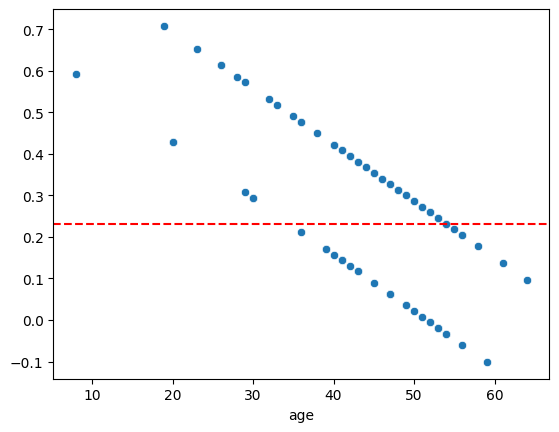

In [ ]:
#Plot of predicted probability of survival by age
import seaborn as sns
import matplotlib.pyplot as plt

y_hat = model.predict(X)
sns.scatterplot(data = tdf, x = 'age', y = y_hat)
plt.axhline(y = ATE, color = 'red', linestyle = 'dashed')

#Since both lines are parallel, the predicted probability for survival decreases with age by the same magnitude for both groups
#Thus, the effect of a transplant is constant across age, so the ATE is not over or underestimating treatment effect

**Q4.4**: Now, include transplant, age, and transplant * age as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

In [32]:
tdf = df.loc[:,['y', 'transplant', 'age']].dropna()
y = tdf['y']

X_cat = pd.get_dummies(tdf['transplant'], dtype = 'int', drop_first = True)
X_num = tdf.loc[:, ['age']]

X_interactions = X_cat.multiply(tdf['age'].values, axis = 0)
X_interactions.columns = [f'{col}_x_age' for col in X_cat.columns]

X = pd.concat([X_num, X_cat, X_interactions], axis = 1)
model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable': X.columns, 'coefficient': model.coef_})

#Allowing age and transplant to interact made the control and transplant have different slopes
#In question 4.3, the treatment and control had the same slopes.
#Since the slopes are now different, the gap between each of the lines gets less as the age increases
#So, age has an interaction on the benefit of a transplant


#Patterns:
#The older a patient is, the smaller the benefit of getting the transplant
#ATE underestimates the benefit of a transplant for younger patients (predicted survival benefit is higher than 0.23)
#ATE overestimates the benefit of a transplant for older patients (predicted survival benefit is smaller than 0.23)

Model intercept: 0.35486517529946177


,variable,coefficient
0,age,-0.005524
1,treatment,0.907751
2,treatment_x_age,-0.014591


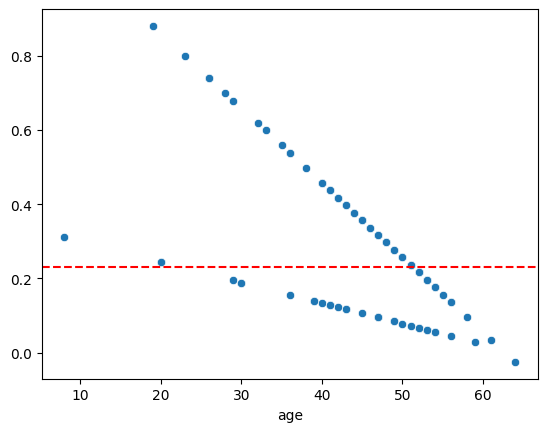

In [ ]:
y_hat = model.predict(X)
sns.scatterplot(data = tdf, x = 'age', y = y_hat)
plt.axhline(y = ATE, color = 'red', linestyle = 'dashed')

**Q4.5**: Use 10-fold cross validation to evaluate the predictive accuracy of these models.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

tdf = df.loc[:,['y', 'transplant', 'age']].dropna()
y = tdf['y'].values

X_cat = pd.get_dummies(tdf['transplant'], dtype = 'int', drop_first = True)
X_num = tdf.loc[:, ['age']]
X_interactions = X_cat.multiply(tdf['age'].values, axis = 0)
X_interactions.columns = [f'{col}_x_age' for col in X_cat.columns]

X_part2 = X_cat.values
X_part3 = pd.concat([X_num, X_cat], axis = 1).values
X_part4 = pd.concat([X_num, X_cat, X_interactions], axis = 1).values

kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

for question, X in [('Question 4.2', X_part2),
                    ('Question 4.3', X_part3),
                    ('Question 4.4', X_part4)]:
  scores = []
  for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    score = mean_squared_error(y_test, y_hat)
    scores.append(score)

  print(f'{question}')
  print('Fold scores', scores)
  print('Mean score', np.mean(scores))
  print('Median score', np.median(scores))
  print('Standard deviation', np.std(scores))

  #Predictive accuracy:
  #The mean MSE and median MSE becomes lower from Question 4.2 to 4.3 and 4.3 to 4.4. This leaves the model from Question 4.4 as the model with the lowest mean and median MSE
  #So, based off of MSE, the model with the highest accuracy is the model from Question 4.4

Question 4.2
Fold scores [0.18488636363636363, 0.2017158052954099, 0.2470096180493702, 0.1737777777777778, 0.240946785475405, 0.1773613130295036, 0.2268283055630207, 0.2268283055630207, 0.10988553590010405, 0.14144803144316048]
Mean score 0.1930687841733136
Median score 0.19330108446588676
Standard deviation 0.04222093390745557
Question 4.3
Fold scores [0.16190327904937485, 0.1838844611617285, 0.2132455222292873, 0.156839121259134, 0.1982974362856225, 0.25082454078821564, 0.22393301156494072, 0.18486278358933364, 0.08362355276636349, 0.11525145716107761]
Mean score 0.17726651658550785
Median score 0.18437362237553107
Standard deviation 0.04763928356649322
Question 4.4
Fold scores [0.15874509049064223, 0.18217597226597704, 0.23087008535221332, 0.145033399017578, 0.1947455750420432, 0.21898896182303956, 0.26511598770056943, 0.17205345389578272, 0.07792587213483734, 0.105549824476285]
Mean score 0.17512042221989677
Median score 0.1771147130808799
Standard deviation 0.05388528399106044


**Q4.6**: Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

I have a few concerns about this being deployed to prioritize transplant access. First, there is no definite causality arising from the predictions the model makes. These are just predictions, which show that transplant recipients have higher survival rates. However, there are other confounding factors that prevent this from being a causal relationship. For example, the sample from the dataset could have just been composed of healthier or younger patients. Thus, using this model to prioritize transplant access would wrongly assume a causal relationship between the coefficients.


Second, since the model predicts that older patients have lower predicted survival probability if they receive a transplant than younger individuals, the model may bar older patients from receiving transplants. This would unfairly disadvantage the elderly without considering important factors such as the severity of their heart disease.


Additionally, in terms of model construction, the model only considers two factors: age and whether the patient received a transplant. These are not sufficient in predicting the true survival probability since other attributes like history of heart disease in the family, severity of disease, and other conditions that may affect surivival like high cholestorol and blood pressure, are not being considered by the model.